# Volatility Surface Modelling for Crypto Options
### A functional library for fitting, comparing and serving implied-volatility surfaces

**Natixis CIB — Quant Analyst Internship**

---

This notebook is a start-to-finish walkthrough of the `volatility_surface` library.
It doubles as the narrative of the project: each section introduces a piece of the
problem, shows the tool we built for it, and — where relevant — the **trials and
errors** that shaped the final design.

By the end you will be able to:

1. Load and clean a Deribit option snapshot into a calibration-ready frame.
2. Instantiate and inspect the four smile models (**Raw SVI, SSVI, eSSVI, SABR**).
3. Calibrate a single slice and a full surface, choosing a fitting **objective**.
4. Compare models on held-out metrics and **check for static arbitrage**.
5. Reproduce the FX-style **Reiswich–Wystup** parabolic smile and see why it
   under-fits crypto wings.
6. Price options under **Black-76 / Black-Scholes / Garman-Kohlhagen** and recover
   the implied funding rate of the inverse contracts.
7. Run the **fast recalibration** path that powers the live trading screen.

> **Runtime note.** Most cells run in well under a second. The three *global*
> calibrations (eSSVI / SSVI / SABR) take **~1–2 minutes each** on a single
> snapshot — they are flagged inline. Run the notebook top-to-bottom once.

## Table of contents

0. [Environment setup](#sec0)
1. [The data pipeline: Deribit → parquet](#sec1)
   * [1b. Exploratory data analysis](#sec1b)
2. [The smile models](#sec2)
3. [Single-slice calibration](#sec3)
4. [Objective functions & the vega-weighting story](#sec4)
5. [Global calibration (eSSVI / SSVI / SABR)](#sec5)
   * [5b. Term structure of fitted vols — strike & delta space](#sec5b)
6. [Model comparison](#sec6)
7. [Static-arbitrage checking](#sec7)
8. [The Reiswich–Wystup parabolic detour](#sec8)
9. [Pricing models & inverse options](#sec9)
10. [Fast recalibration (production speed)](#sec10)
11. [The live system](#sec11)
12. [Trials & errors](#sec12)
13. [Conclusion & next steps](#sec13)

<a id="sec0"></a>
## 0. Environment setup

We locate the project root (the folder containing `2 - Data`), put it on the
import path, and pull in every public entry point we will use.

In [17]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import os, sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110})

# Walk up until we find the project root (contains "2 - Data")
here = Path.cwd()
PROJECT_ROOT = next((p for p in [here, *here.parents] if (p / "2 - Data").exists()), here)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

PARQUET_ETH = PROJECT_ROOT / "2 - Data" / "parquets" / "eth_options_data_cleaned.parquet"
PARQUET_BTC = PROJECT_ROOT / "2 - Data" / "parquets" / "btc_options_data_cleaned.parquet"
print("ETH archive exists:", PARQUET_ETH.exists())

Project root: /Users/macbookair/Internship Natixis
ETH archive exists: True


In [19]:
# Library entry points
from volatility_surface.models.vol_models import get_model, MODELS, RawSVI, SSVI, SABR, eSSVI
from volatility_surface.core.calibration.calibrator import (
    load_snapshot, calibrate_snapshot,
    calibrate_global_essvi, calibrate_global_ssvi, calibrate_global_sabr,
    calibrate_global_essvi_update, calibrate_snapshot_sabr_update,
    summary, compare, crossedness,
)
from volatility_surface.core.calibration.objectives import (
    get_objective, OBJECTIVES, evaluate_all, DEFAULT_METRICS, optimize_beta,
)
from volatility_surface.plots.vol_plots import (
    plot_all, plot_slices, plot_surface, plot_total_variance,
    plot_metrics, plot_compare,
)
from volatility_surface.utils.arbitrage_checker import check_arbitrage, plot_arbitrage_map
from volatility_surface.models.rw_parabolic import (
    fit_paper_style, fit_least_squares, sigma_of_K, RWParams,
)
from volatility_surface.core.pricing.pricing_models import bs_price, gk_price

print("Models available :", list(MODELS.keys()))
print("Objectives       :", list(OBJECTIVES.keys()))
print("Default metrics  :", DEFAULT_METRICS)

Models available : ['svi', 'ssvi', 'sabr', 'essvi']
Objectives       : ['w_mse', 'iv_mse', 'iv_wmse', 'price_mse', 'iv_rmse', 'vega_wmse', 'band', 'vega_wmse_band', 'iv_zweighted', 'iv_uniform_z', 'iv_convex_blend', 'iv_replication']
Default metrics  : ['iv_rrmse', 'spread_hit_rate', 'price_vwrrmse', 'w_rmse', 'vwrmse', 'vwrrmse', 'iv_rmse_atm', 'iv_rmse_otm']


<a id="sec1"></a>
## 1. The data pipeline: Deribit → parquet

Crypto option quotes come from **Deribit**, the dominant venue for BTC/ETH options.
The raw feed is a per-instrument book summary (one row per listed option). Our
offline pipeline (`utils/data_handling.clean_df`) and the live gatherer
(`live_gather.clean_live`) both turn that into a **calibration-ready frame** with:

| column | meaning |
|---|---|
| `k` | log-moneyness $\ln(K/F)$ |
| `t` | time to expiry in years |
| `w` | total variance $\sigma_{\text{mark}}^2\,t$ |
| `mark_iv` | Deribit mark implied vol |
| `bid_iv` / `ask_iv` | implied vols inverted from bid/ask **prices** (via `vollib`) |
| `vega` | analytic Black vega, used as the default fitting weight |
| `underlying_price` | per-expiry **forward** $F$ |
| `estimated_delivery_price` | **spot** index $S$ |

The cleaning enforces an **OTM-only** filter for calibration (calls with $k\ge 0$,
puts with $k\le 0$) so that put–call parity duplicates don't double-weight strikes.

In [20]:
raw = pd.read_parquet(PARQUET_ETH)
print(f"ETH archive: {len(raw):,} rows across {raw['file_timestamp'].nunique()} snapshots")
print("Columns:", list(raw.columns))
raw[["file_timestamp", "strike", "option_type", "t", "k",
     "mark_iv", "bid_iv", "ask_iv", "vega", "underlying_price"]].head()

ETH archive: 3,771 rows across 16 snapshots
Columns: ['bid_price', 'ask_price', 'open_interest', 'mark_price', 'creation_timestamp_x', 'volume', 'mark_iv', 'underlying_price', 'underlying_index', 'estimated_delivery_price', 'mid_price', 'price_index', 'expiration_timestamp', 'strike', 'settlement_period', 'option_type', 'instrument_id', 'expiration_timestamp_ms', 'file_timestamp', 't', 'k', 'w', 'vega', 'bid_iv', 'ask_iv', 'half_spread_iv', 'half_spread', 'bid_size', 'ask_size']


,file_timestamp,strike,option_type,t,k,mark_iv,bid_iv,ask_iv,vega,underlying_price
0,2026-06-04 20:06,64500,C,0.006837,0.019782,0.4291,0.412464,0.447520,0.028514,63236.59
1,2026-06-04 20:06,140000,C,0.557522,0.776612,0.4679,0.464297,0.475035,0.036565,64394.64
2,2026-06-04 20:06,90000,C,0.308207,0.343894,0.4013,0.401506,0.407682,0.079417,63810.35
3,2026-06-04 20:06,250000,C,0.557522,1.356408,0.6042,0.580273,0.627856,0.006231,64396.07
4,2026-06-04 20:06,70000,C,0.806837,0.073991,0.4464,0.443983,0.450961,0.358301,65007.62


In [21]:
# load_snapshot() pulls a single timestamp and re-derives k, w, t cleanly.
snapshots = sorted(raw["file_timestamp"].unique())
SNAP_TS = snapshots[-1]
df = load_snapshot(str(PARQUET_ETH), timestamp=SNAP_TS)

expiries = sorted(df["t"].unique())
print(f"Snapshot {SNAP_TS}: {len(df)} quotes, {len(expiries)} expiries")
print("Expiries (days):", [round(t*365, 1) for t in expiries])

  202 rows in snapshot
  202 rows after cleaning (dropped 0)
Snapshot 2026-06-30 15:04: 202 quotes, 12 expiries
Expiries (days): [0.7, 1.7, 2.7, 3.7, 9.7, 16.7, 30.7, 58.7, 86.7, 177.7, 268.7, 359.7]


Full snapshot: 202 quotes  ->  OTM-only: 202 quotes


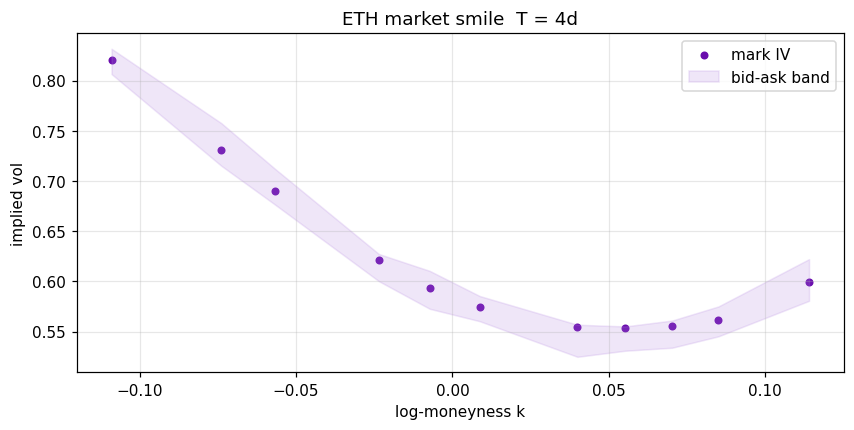

In [22]:
# OTM-only view used for all calibration below
otm = ((df["option_type"] == "C") & (df["k"] >= 0)) | \
      ((df["option_type"] == "P") & (df["k"] <= 0))
df_otm = df[otm].copy()
print(f"Full snapshot: {len(df)} quotes  ->  OTM-only: {len(df_otm)} quotes")

# Quick look at one expiry's smile
T0 = expiries[3]
sl = df_otm[np.isclose(df_otm["t"], T0)].sort_values("k")
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(sl["k"], sl["mark_iv"], s=18, c="#6A0DAD", label="mark IV")
ax.fill_between(sl["k"], sl["bid_iv"], sl["ask_iv"], alpha=0.2, color="#B284E0", label="bid-ask band")
ax.set(xlabel="log-moneyness k", ylabel="implied vol",
       title=f"ETH market smile  T = {T0*365:.0f}d")
ax.legend(); plt.show()

<a id="sec1b"></a>
## 1b. Exploratory data analysis

Before fitting anything it pays to look at what is actually in the tin.
Everything below is computed **on the single snapshot loaded above** — no
multi-date averaging, no smoothing.

**Important**: the plots below use the **unfiltered** universe
(`load_uncleaned`), not the calibration-ready parquet (`raw`/`df`). The
parquet has already dropped zero-volume quotes, no-arb boundary violations,
and everything ITM — running EDA on it would hide exactly the composition
(how much is illiquid, how much is ITM, how wide ITM spreads are) that
motivated those filters in the first place. As the cell below shows, only
a minority of listed ETH quotes survive the full cleaning pipeline.

Five views that reveal most of what matters:

0. **Cleaning attrition** — how much of the raw chain survives to calibration.
1. **Snapshot inventory** — how many quotes, how many expiries, how many
   strikes, and how much of that survives cleaning, per archived snapshot.
2. **Open interest by expiry** — where the money is parked in maturity terms
   (full chain, ITM + OTM).
3. **Open interest by strike** — where the market thinks the interesting price
   levels are (put walls, call walls, gamma pins).
4. **Bid-ask half-spread by moneyness** — a liquidity fingerprint, comparing
   the OTM side (kept by calibration) against the mirrored ITM side (dropped)
   at the same moneyness bucket.

In [23]:
# Full, UNFILTERED universe — every listed quote, before volume / no-arb-boundary /
# OTM / bid-ask-inversion filters. The cleaned parquet used everywhere else in this
# notebook has already survived those filters, which would bias any EDA run on it
# (e.g. "how much open interest sits in deep ITM strikes" is unanswerable once ITM
# rows are already gone). load_uncleaned() reruns the same feature engineering as
# clean_df() but skips the row-dropping steps.
from volatility_surface.utils.data_handling import load_uncleaned

raw_uncleaned = load_uncleaned("eth")
n_total   = len(raw_uncleaned)
n_volume  = int((raw_uncleaned["volume"] > 0).sum())
n_cleaned = len(raw)

print(f"ETH quotes across all archived snapshots:")
print(f"  {n_total:>6,} listed (uncleaned)")
print(f"  {n_volume:>6,} with volume > 0  ({n_volume/n_total:.1%})")
print(f"  {n_cleaned:>6,} survive the full cleaning pipeline used for calibration  "
      f"({n_cleaned/n_total:.1%})")

# Single-snapshot slice matching SNAP_TS, for the plots below
df_uncleaned = raw_uncleaned[raw_uncleaned["file_timestamp"] == SNAP_TS].copy()
print(f"\nSnapshot {SNAP_TS}: {len(df_uncleaned)} listed quotes "
      f"vs. {len(df)} that survived cleaning ({len(df)/len(df_uncleaned):.1%})")

ETH quotes across all archived snapshots:
  12,080 listed (uncleaned)
   5,598 with volume > 0  (46.3%)
   3,771 survive the full cleaning pipeline used for calibration  (31.2%)

Snapshot 2026-06-30 15:04: 688 listed quotes vs. 202 that survived cleaning (29.4%)


In [24]:
# Snapshot inventory — one row per timestamp, computed on the UNFILTERED universe.
cleaned_counts = raw.groupby("file_timestamp").size().rename("n_cleaned")

inventory = (raw_uncleaned.groupby("file_timestamp")
             .agg(n_quotes    = ("strike",           "size"),
                  n_expiries  = ("t",                pd.Series.nunique),
                  n_strikes   = ("strike",           pd.Series.nunique),
                  F_median    = ("underlying_price", "median"),
                  min_exp_d   = ("t", lambda s: round(s.min()*365, 1)),
                  max_exp_d   = ("t", lambda s: round(s.max()*365, 1)),
                  atm_iv_med  = ("mark_iv",          "median"))
             .join(cleaned_counts, on="file_timestamp")
             .reset_index())
inventory["pct_kept"] = (inventory["n_cleaned"] / inventory["n_quotes"]).round(3)
print(f"{len(inventory)} archived ETH snapshots.")
inventory

16 archived ETH snapshots.


,file_timestamp,n_quotes,n_expiries,n_strikes,F_median,min_exp_d,max_exp_d,atm_iv_med,n_cleaned,pct_kept
0,2026-05-21 13:41,728,12,79,2110.13,0.8,308.8,0.58845,215,0.295
1,2026-05-21 13:42,728,12,79,2111.50,0.8,308.8,0.58845,215,0.295
2,2026-05-21 13:43,728,12,79,2111.74,0.8,308.8,0.58835,215,0.295
3,2026-05-21 13:44,728,12,79,2107.77,0.8,308.8,0.58870,215,0.295
4,2026-05-21 13:45,728,12,79,2109.68,0.8,308.8,0.58920,215,0.295
5,2026-05-22 14:42,724,12,79,2119.51,0.7,307.7,0.57180,228,0.315
6,2026-05-27 11:26,700,11,80,2084.33,0.9,302.9,0.57510,205,0.293
7,2026-05-27 11:43,700,11,80,2081.42,0.8,302.8,0.57600,206,0.294
8,2026-05-28 09:42,780,13,82,1992.63,0.9,301.9,0.58400,232,0.297
9,2026-06-02 07:26,708,12,79,1984.33,0.0,297.0,0.57070,228,0.322


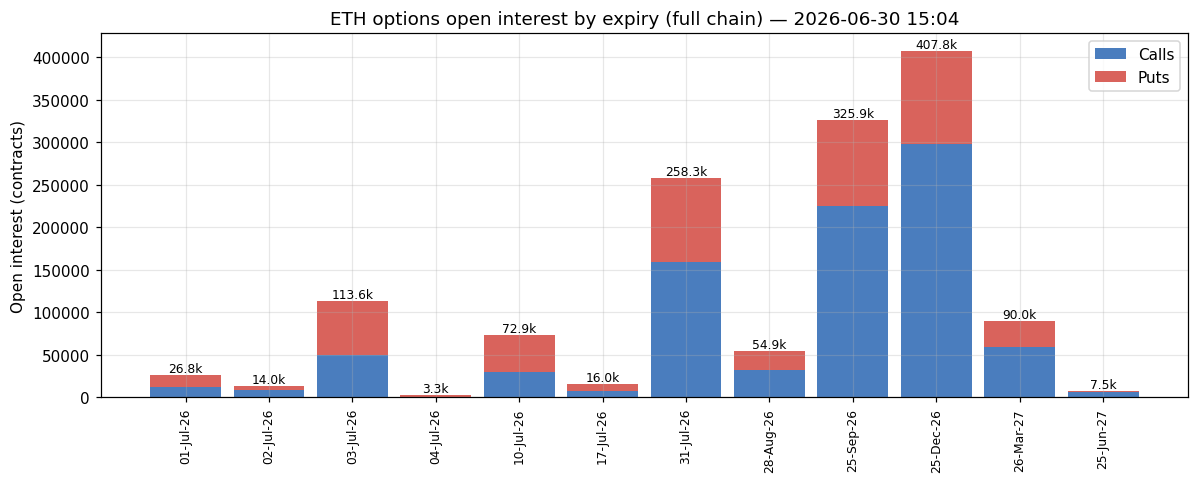

In [25]:
# Open interest by expiration date (stacked calls + puts) — FULL chain, ITM + OTM.
oi_exp = (df_uncleaned.groupby(["expiration_timestamp", "option_type"])["open_interest"]
          .sum().unstack("option_type").fillna(0.0).sort_index()
          .rename(columns={"C": "Calls", "P": "Puts"}))
labels = [pd.Timestamp(x).strftime("%d-%b-%y") for x in oi_exp.index]
x   = np.arange(len(oi_exp))
tot = oi_exp.sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x, oi_exp.get("Calls", 0), color="#4A7DBE", label="Calls", width=0.85)
ax.bar(x, oi_exp.get("Puts", 0),  bottom=oi_exp.get("Calls", 0),
       color="#D9635C", label="Puts", width=0.85)
for i, v in enumerate(tot):
    ax.annotate(f"{v/1000:.1f}k", (i, v), ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set(ylabel="Open interest (contracts)",
       title=f"ETH options open interest by expiry (full chain) — {SNAP_TS}")
ax.legend()
plt.tight_layout(); plt.show()

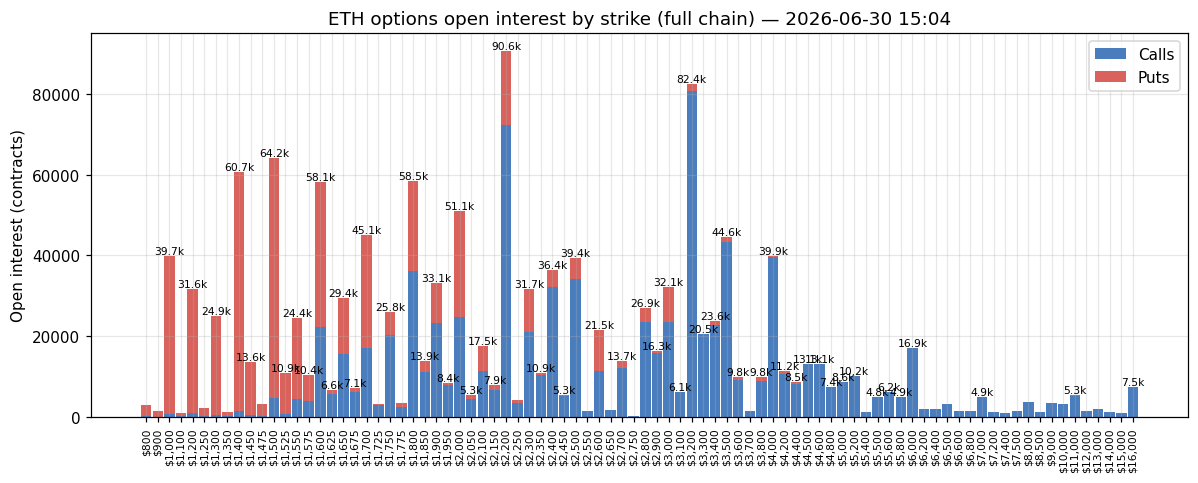

In [26]:
# Open interest by strike (stacked calls + puts) — FULL chain, ITM + OTM.
oi_k = (df_uncleaned.groupby(["strike", "option_type"])["open_interest"]
        .sum().unstack("option_type").fillna(0.0).sort_index()
        .rename(columns={"C": "Calls", "P": "Puts"}))
labels = [f"${int(x):,}" for x in oi_k.index]
x   = np.arange(len(oi_k))
tot = oi_k.sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x, oi_k.get("Calls", 0), color="#4A7DBE", label="Calls", width=0.9)
ax.bar(x, oi_k.get("Puts", 0),  bottom=oi_k.get("Calls", 0),
       color="#D9635C", label="Puts", width=0.9)
for i, v in enumerate(tot):
    if v > tot.max() * 0.05:      # skip near-empty bars to avoid clutter
        ax.annotate(f"{v/1000:.1f}k", (i, v), ha="center", va="bottom", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set(ylabel="Open interest (contracts)",
       title=f"ETH options open interest by strike (full chain) — {SNAP_TS}")
ax.legend()
plt.tight_layout(); plt.show()

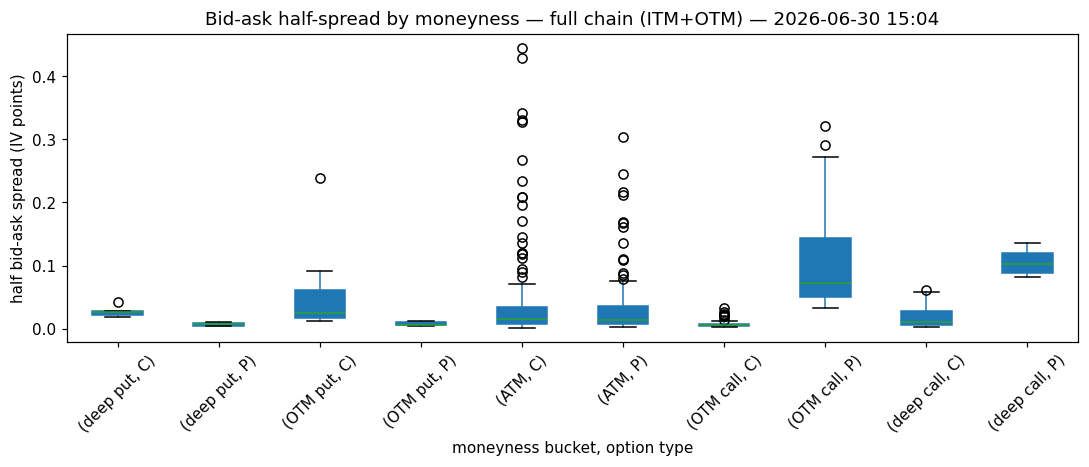

In [27]:
# Bid-ask half-spread by moneyness AND option side — SINGLE snapshot, FULL chain.
# Same moneyness bucket, split by option_type, shows exactly what OTM-only
# filtering buys: the ITM side of each bucket is the mirror-image quote
# calibration throws away, and it is consistently the wider/noisier one.
# (NaN half-spreads, from quotes where IV inversion failed on the unfiltered
# universe, are dropped implicitly by the bounds mask below.)
qq = df_uncleaned[(df_uncleaned["half_spread_iv"] > 0) & (df_uncleaned["half_spread_iv"] < 1)].assign(
    k_bucket=lambda d: pd.cut(
        d["k"],
        bins=[-2.0, -0.5, -0.2, 0.2, 0.5, 2.0],
        labels=["deep put", "OTM put", "ATM", "OTM call", "deep call"],
    )
)
fig, ax = plt.subplots(figsize=(10, 4.5))
qq.boxplot(column="half_spread_iv", by=["k_bucket", "option_type"], ax=ax,
          grid=False, patch_artist=True, rot=45)
ax.set(xlabel="moneyness bucket, option type", ylabel="half bid-ask spread (IV points)",
       title=f"Bid-ask half-spread by moneyness — full chain (ITM+OTM) — {SNAP_TS}")
plt.suptitle("")
plt.tight_layout(); plt.show()

<a id="sec2"></a>
## 2. The smile models

Every model subclasses `VolModel` and implements `w(k, params)` — the total
variance. Implied vol is `iv = sqrt(w / t)`, and the risk-neutral density comes
from `butterfly_density(k, params)` (Breeden–Litzenberger).

| model | per-slice params | global params | $w(k)$ form |
|---|---|---|---|
| **Raw SVI** | $a, b, \rho, m, \sigma$ | – | $a + b[\rho(k-m)+\sqrt{(k-m)^2+\sigma^2}]$ |
| **SSVI** | $\theta$ | $\eta,\gamma,\rho$ | Gatheral–Jacquier surface |
| **eSSVI** | $\theta,\eta,\gamma$ | $\rho_0,\rho_\infty,\lambda$ | $\rho(\theta)=\rho_\infty+(\rho_0-\rho_\infty)e^{-\lambda\theta}$ |
| **SABR** | $\alpha,\rho,\nu$ ($\beta$ fixed) | – | Hagan (2002) lognormal expansion |

The registry `get_model("svi" | "ssvi" | "essvi" | "sabr", **kwargs)` returns an
instance.

In [28]:
for name in ["svi", "ssvi", "essvi", "sabr"]:
    m = get_model(name)
    k = sl["k"].values
    w_obs = sl["w"].values
    guess = m.initial_guess(k, w_obs, T0)
    print(f"{m.name:>10s}  initial guess: { {kk: round(v,3) for kk,v in guess.items()} }")

   Raw SVI  initial guess: {'a': 0.003, 'b': 0.1, 'rho': -0.7, 'm': 0.0, 'sig': 0.3}
      SSVI  initial guess: {'theta': 0.003, 'eta': 2.0, 'rho': -0.7, 'gamma': 0.4}
     eSSVI  initial guess: {'theta': 0.003, 'eta': 1.5, 'gamma': 0.4, 'rho_0': -0.8, 'rho_inf': -0.3, 'lam': 2.0}
      SABR  initial guess: {'alpha': 0.584, 'rho': -0.5, 'nu': 0.5, 't': 0.01}


### Drawing a smile and its risk-neutral density from hand-set parameters

A `VolModel` is a pure function of its parameter dict — handy for intuition. Here is
a Raw SVI slice and the implied density it generates (negative density = butterfly
arbitrage).

Butterfly-arbitrage free: True (min g = 0.2014 )


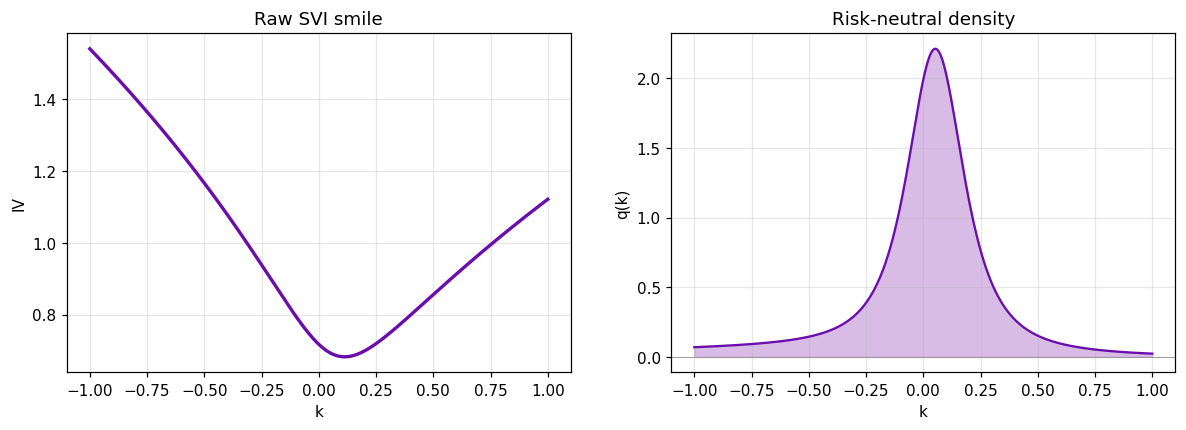

In [29]:
svi = RawSVI()
params = {"a": 0.04, "b": 0.40, "rho": -0.30, "m": 0.05, "sig": 0.20}
kk = np.linspace(-1.0, 1.0, 401)
iv = svi.iv(kk, params, t=0.25)
dens = svi.butterfly_density(kk, params)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(kk, iv, c="#6A0DAD", lw=2.2); a1.set(xlabel="k", ylabel="IV", title="Raw SVI smile")
a2.fill_between(kk, np.maximum(dens, 0), color="#C9A0DC", alpha=0.7)
a2.plot(kk, dens, c="#6A0DAD", lw=1.5); a2.axhline(0, c="#999", lw=0.6)
a2.set(xlabel="k", ylabel="q(k)", title="Risk-neutral density")
print("Butterfly-arbitrage free:", not svi.has_butterfly_arb(params),
      "(min g =", round(svi.min_g(params), 4), ")")
plt.show()

<a id="sec3"></a>
## 3. Single-slice calibration

`calibrate_snapshot(df, model, objective, ...)` fits every expiry independently
(for per-slice models like Raw SVI and SABR). It runs a global differential-evolution
search followed by a Nelder–Mead polish, with **soft penalties** for negative
variance, butterfly arbitrage, and calendar crossing with neighbouring slices.

We pass the bid/ask IV columns so liquidity-aware metrics like `spread_hit_rate`
(fraction of fitted IVs landing inside the quoted band) can be evaluated.

In [30]:
# Raw SVI, per-slice. (~30-60 s: DE + NM on each expiry.)
t0 = time.perf_counter()
res_svi = calibrate_snapshot(
    df_otm, model=RawSVI(), objective="vega_wmse",
    vega_col="vega", bid_col="bid_iv", ask_col="ask_iv", verbose=False,
)
print(f"Calibrated {len(res_svi['expiries'])} slices in {time.perf_counter()-t0:.1f}s")
summary(res_svi)

Calibrated 12 slices in 19.1s

──────────────────────────────────────────────────────────────────────
  Model     : Raw SVI
  Objective : obj_iv_vega_wmse
──────────────────────────────────────────────────────────────────────
       T     n      iv_rrmse  spread_hit_rate  price_vwrrmse        w_rmse        vwrmse       vwrrmse   iv_rmse_atm   iv_rmse_otm
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  0.0019    12      0.270402      0.166667      0.306601      0.000542      0.109336      0.141971      0.021753      0.265503
  0.0047    13      0.009340      1.000000      0.027290      0.000040      0.003039      0.004572      0.001212      0.008214
  0.0074    18      0.018400      0.833333      0.048161      0.000194      0.005670      0.007229      0.001579      0.019768
  0.0102    11      0.003496      1.000000      0.011183      0.000030      0.001480      0.002544      0.000879      0.002876
  0.

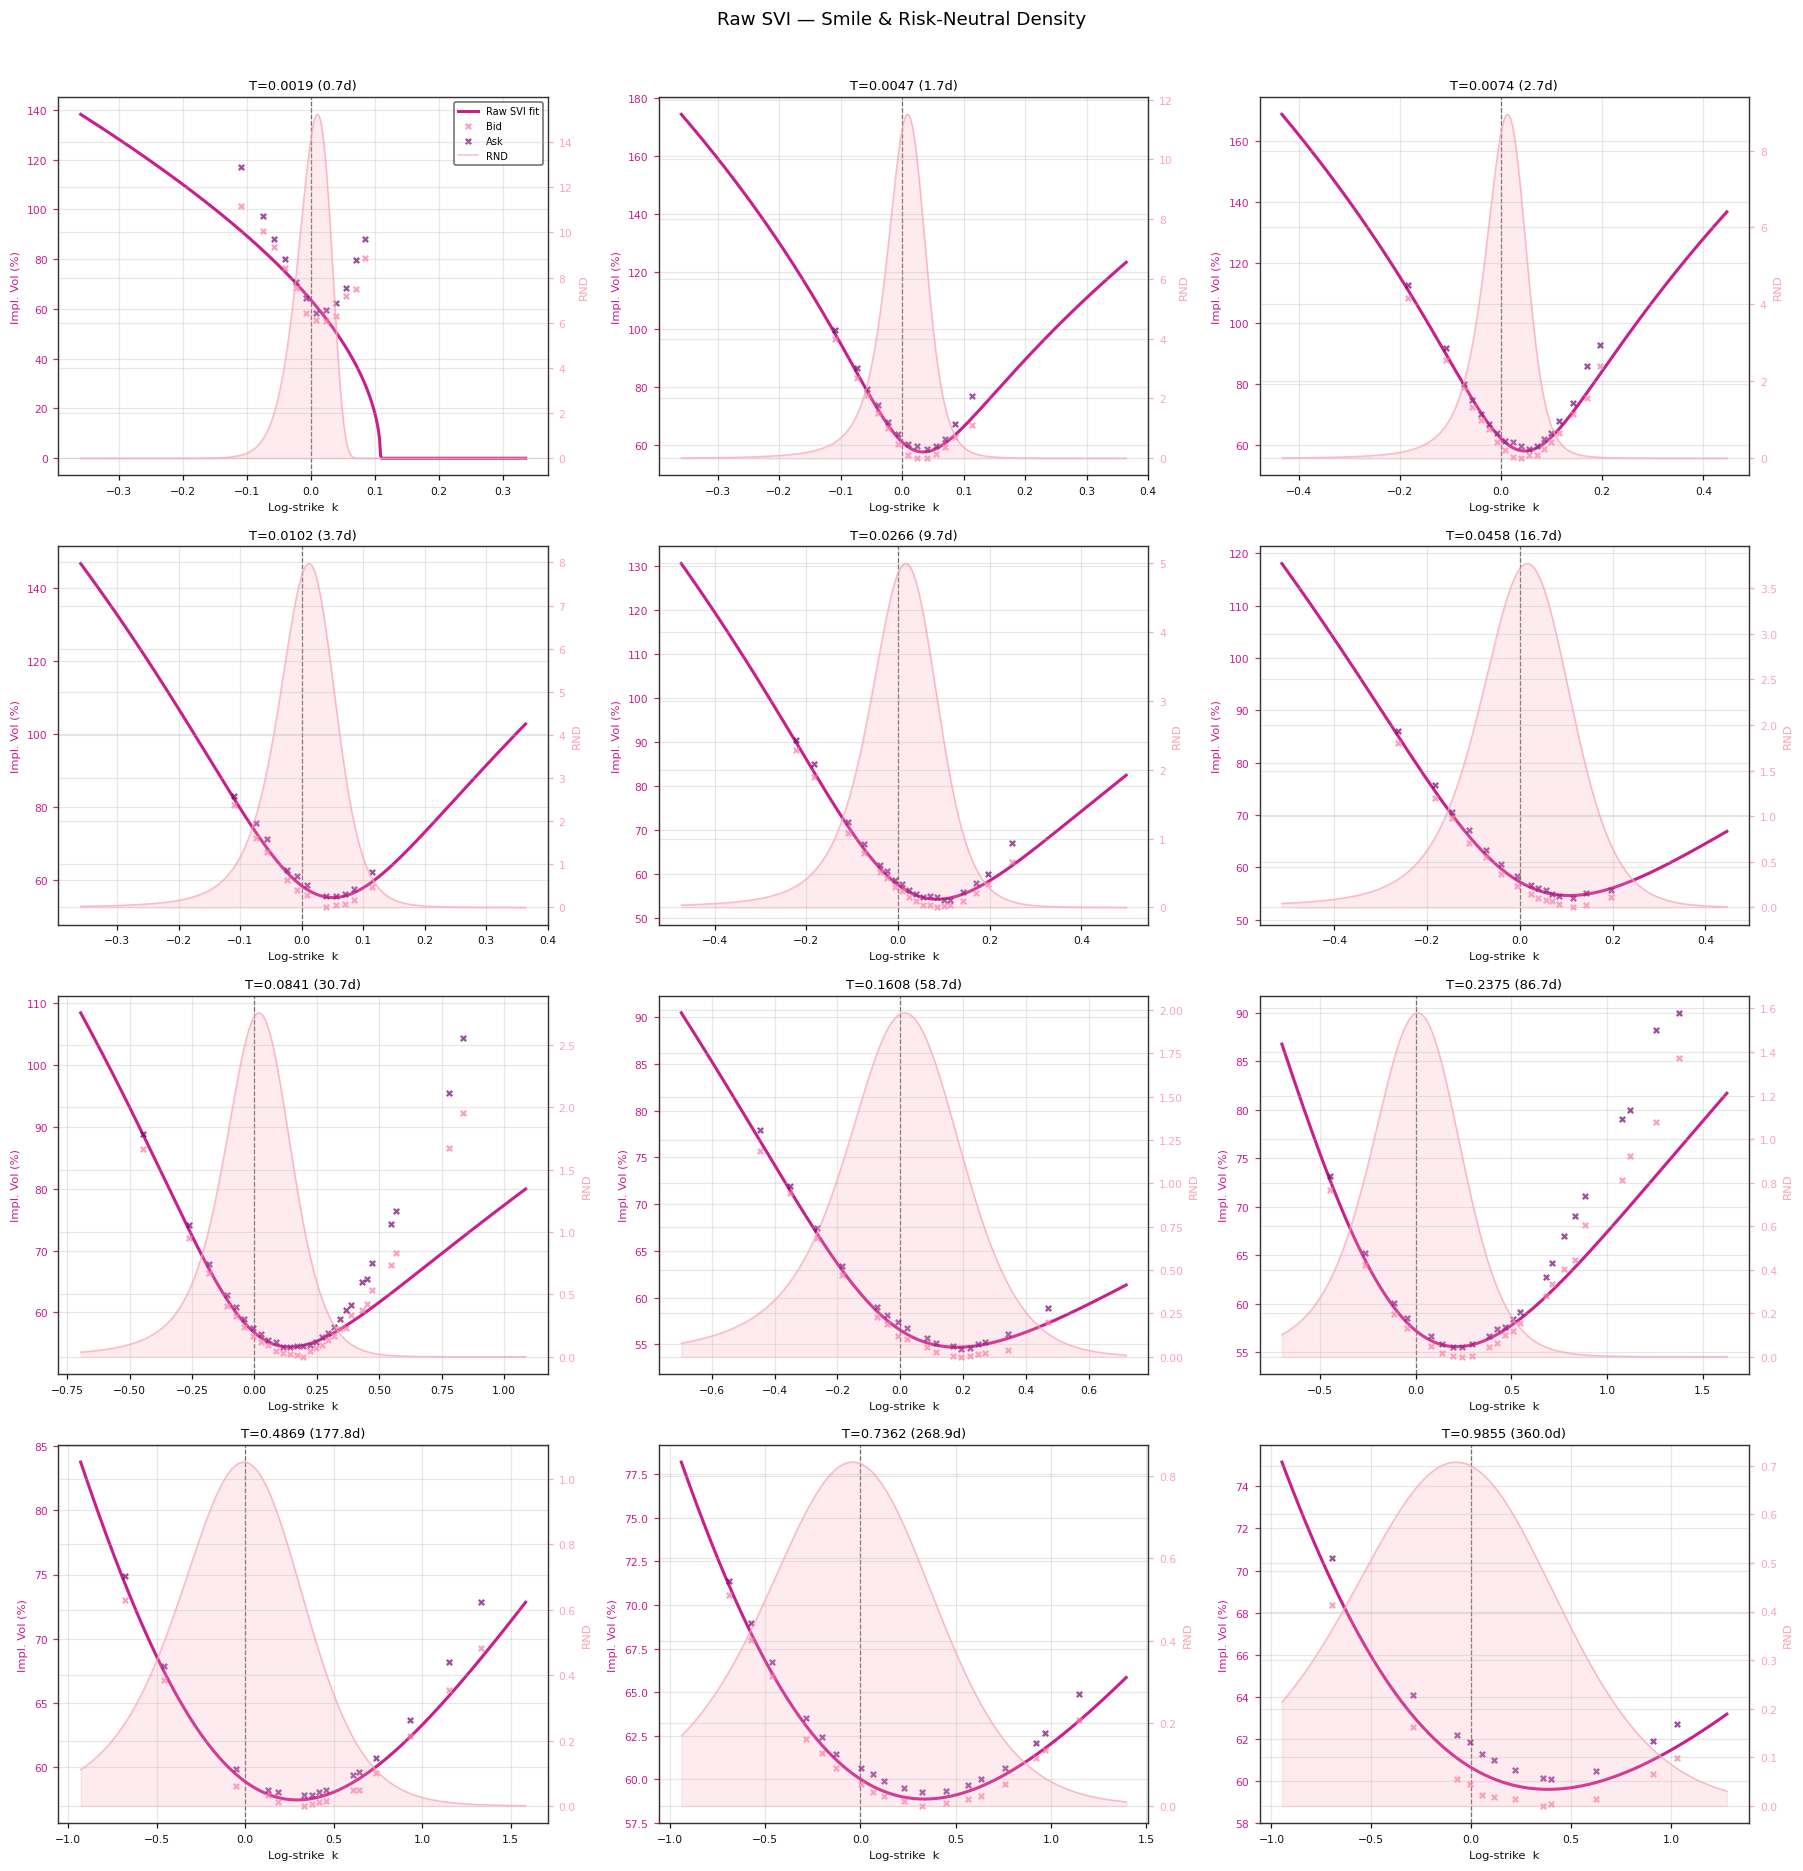

In [31]:
# Per-slice fitted smiles with the market scatter + the implied RND on each.
fig = plot_slices(res_svi, df=df_otm)
plt.show()

<a id="sec4"></a>
## 4. Objective functions & the vega-weighting story

The **objective** decides *which strikes the fit cares about*. All objectives share
the signature `f(w_fit, w_obs, iv_fit, iv_obs, k, t, spreads=...)` and are looked up
by name from `OBJECTIVES`.

Key members:

- `iv_mse` — unweighted (every quote equal; over-weights illiquid wings).
- `vega_wmse` — **vega-weighted** MSE in vol space ($\propto$ vega$^2/$spread$^2$): the
  FactSet-style default. ATM-dominated and liquidity-aware.
- `iv_zweighted(β)` — vega weighting with a standardised-moneyness boost
  $\exp(\beta z^2)$ that controls how much the wings count. $\beta=0$ is pure vega,
  $\beta=0.5$ ≈ uniform-in-$z$.
- `band` / `vega_wmse_band` — explicitly penalise leaving the bid-ask book.

> **Trial & error.** On a handful of ETH dates, `iv_zweighted(β=0.4)` looked best for
> `spread_hit_rate`. But across *more* snapshots the advantage evaporated and plain
> **vega-weighting (β=0)** was the robust choice — so the live system uses
> `vega_wmse`. The lesson: one snapshot is an anecdote, not a result.

In [32]:
# Score a fitted result on every default metric (locate the slice by nearest T).
i_svi = int(np.argmin(np.abs(np.asarray(res_svi["expiries"]) - T0)))
p_svi = res_svi["params"][i_svi]
mdl   = res_svi["_model"]
evals = evaluate_all(
    w_fit=mdl.w(sl["k"].values, p_svi),
    w_obs=sl["w"].values,
    iv_fit=mdl.iv(sl["k"].values, p_svi, T0),
    iv_obs=sl["mark_iv"].values,
    k=sl["k"].values, t=T0,
    bid=sl["bid_iv"].values, ask=sl["ask_iv"].values,
)
pd.Series(evals).round(4).to_frame("value (mid expiry, Raw SVI)")

,"value (mid expiry, Raw SVI)"
iv_rrmse,0.0035
spread_hit_rate,1.0000
price_vwrrmse,0.0112
w_rmse,0.0000
vwrmse,0.0015
vwrrmse,0.0025
iv_rmse_atm,0.0009
iv_rmse_otm,0.0029


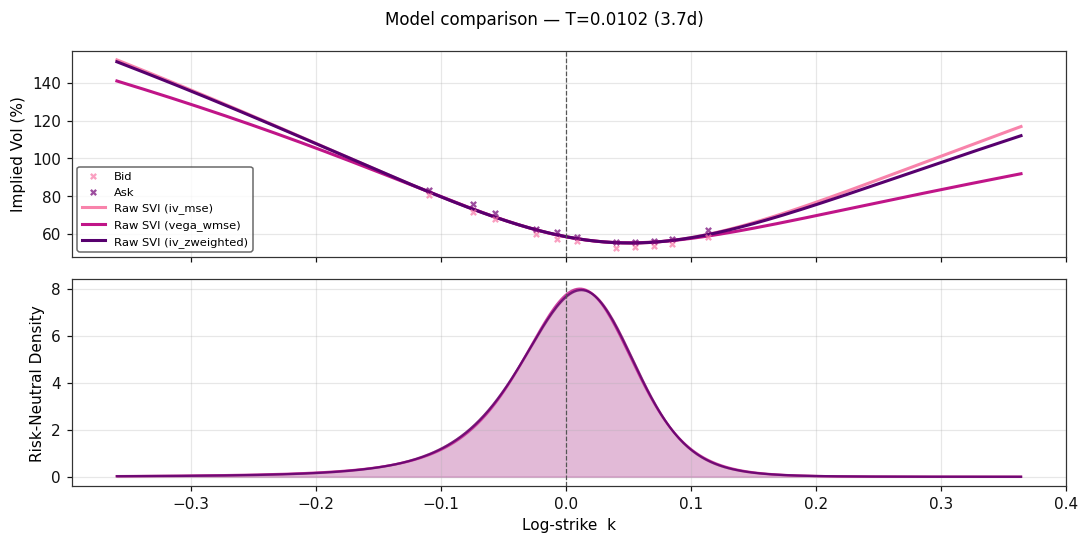

In [33]:
# Overlay three objectives on a SINGLE expiry to see the weighting effect.
results_obj = []
for obj in ["iv_mse", "vega_wmse", "iv_zweighted"]:
    r = calibrate_snapshot(
        df_otm[np.isclose(df_otm["t"], T0)], model=RawSVI(), objective=obj,
        vega_col="vega", bid_col="bid_iv", ask_col="ask_iv", verbose=False,
    )
    r["objective"] = obj
    results_obj.append(r)

fig = plot_compare(results_obj, df=df_otm[np.isclose(df_otm["t"], T0)], t_exp=T0)
plt.show()

<a id="sec5"></a>
## 5. Global calibration (eSSVI / SSVI / SABR)

Per-slice fits are flexible but can **cross in maturity** (calendar arbitrage).
Global models share parameters across expiries to enforce a coherent surface.

- `calibrate_global_essvi` — 3 global $(\rho_0,\rho_\infty,\lambda)$ + 3 per slice.
- `calibrate_global_ssvi` — 3 global $(\eta,\gamma,\rho)$ + 1 per slice; provably
  arb-free under the GJ conditions.
- `calibrate_global_sabr` — per-slice SABR with calendar coupling.

> **Runtime: ~1–2 minutes each** on this snapshot.

In [34]:
t0 = time.perf_counter()
res_essvi = calibrate_global_essvi(
    df_otm, model=eSSVI(), objective="vega_wmse",
    vega_col="vega", bid_col="bid_iv", ask_col="ask_iv", verbose=False,
)
print(f"eSSVI global fit: {time.perf_counter()-t0:.1f}s")
summary(res_essvi)

eSSVI global fit: 8.4s

──────────────────────────────────────────────────────────────────────
  Model     : eSSVI
  Objective : obj_iv_vega_wmse
──────────────────────────────────────────────────────────────────────
       T     n      iv_rrmse  spread_hit_rate  price_vwrrmse        w_rmse        vwrmse       vwrrmse   iv_rmse_atm   iv_rmse_otm
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  0.0019    12      0.053553      0.666667      0.128791      0.000153      0.020579      0.025517      0.003633      0.054202
  0.0047    13      0.015638      0.923077      0.035002      0.000098      0.008870      0.011459      0.004916      0.015875
  0.0074    18      0.041086      0.500000      0.092842      0.000455      0.014593      0.017898      0.002259      0.045398
  0.0102    11      0.010961      0.818182      0.030244      0.000099      0.005702      0.008999      0.003299      0.009783
  0.0266    1

In [35]:
t0 = time.perf_counter()
res_ssvi = calibrate_global_ssvi(
    df_otm, objective="vega_wmse",
    vega_col="vega", bid_col="bid_iv", ask_col="ask_iv", verbose=False,
)
print(f"SSVI global fit: {time.perf_counter()-t0:.1f}s")

# t0 = time.perf_counter()
# res_sabr = calibrate_global_sabr(
#     df_otm, objective="vega_wmse",
#     vega_col="vega", bid_col="bid_iv", ask_col="ask_iv", verbose=False,
# )
# print(f"SABR global fit: {time.perf_counter()-t0:.1f}s")

SSVI global fit: 44.2s


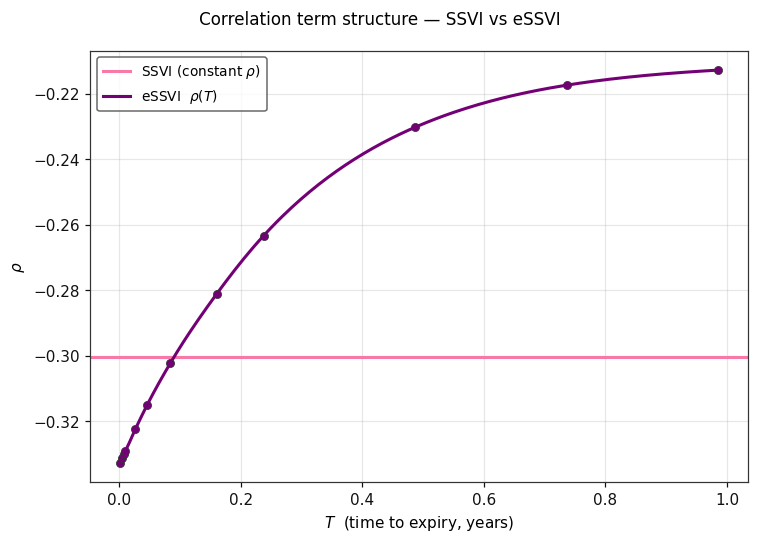

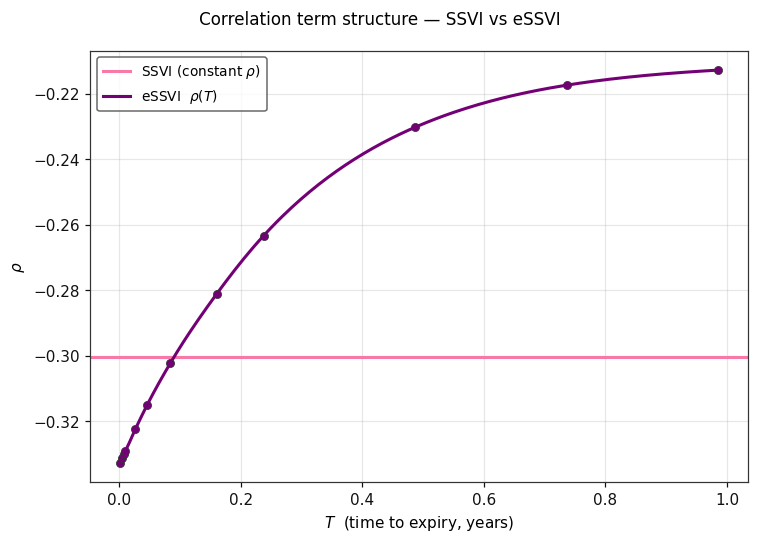

In [36]:
from volatility_surface.plots.vol_plots import plot_rho_comparison
plot_rho_comparison(res_ssvi, res_essvi)

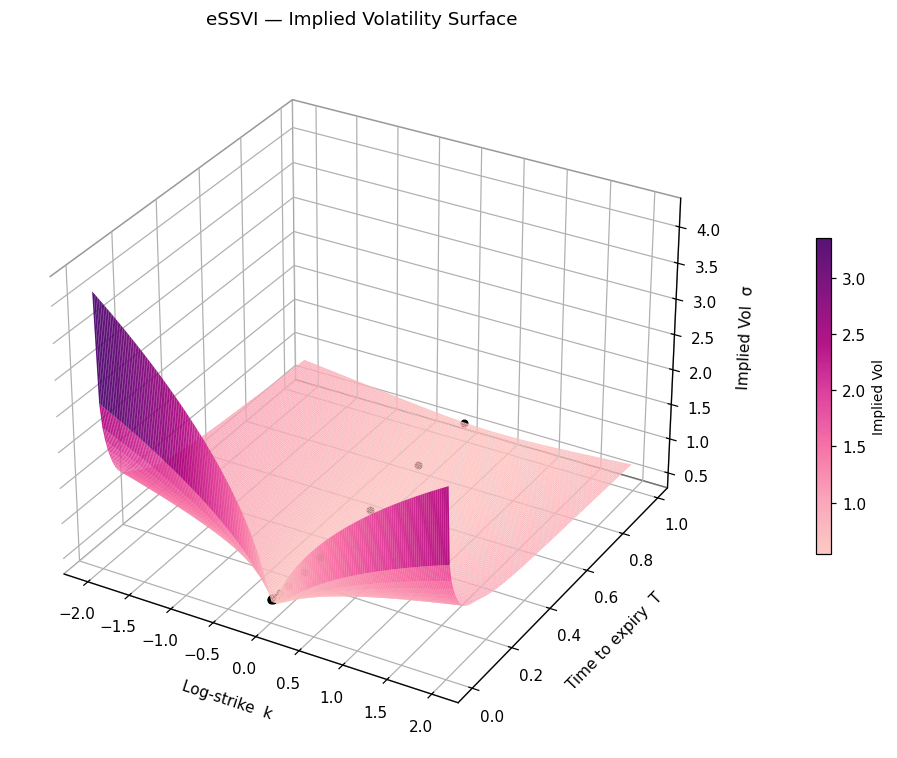

In [37]:
# eSSVI fitted surface (left: smile heatmap; right: term structure of theta)
fig = plot_surface(res_essvi)
plt.show()

<a id="sec5b"></a>
### 5b. Term structure of fitted vols — one snapshot, two views

A classic post-calibration diagnostic (Reiswich–Wystup, Sepp): plot every fitted
smile from **the same snapshot** on a shared x-axis, coloured by expiry. We show
two views back-to-back:

- **Strike space** (top) — makes it obvious that short expiries have narrower
  strike coverage and steeper wings; long expiries flatten and broaden.
- **Forward call-delta space** (bottom) — puts every expiry on a common
  moneyness axis. The ATM level shift with maturity (contango vs backwardation)
  becomes a vertical stack; the skew shape becomes the slope.

The delta view is what traders quote in — a "0.25Δ RR" is well-defined at every
expiry only because you can locate the +0.25Δ call and −0.25Δ put on that axis.

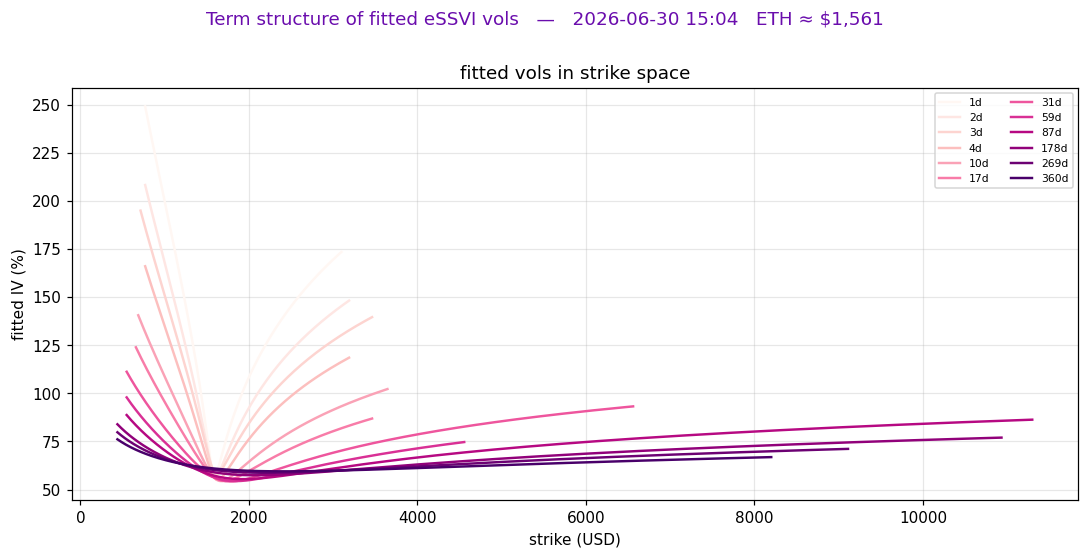

In [38]:
# Reiswich-style diagnostic: every fitted slice from the CURRENT snapshot on the
# same x-axis, coloured by expiry. Two panels: strike space (top) and forward
# call-delta space (bottom).
from scipy.stats import norm

def _fitted_ts_in_strike(res, dfoto, ax, k_pad=0.6):
    model = res["_model"]; cmap = plt.cm.RdPu; n = len(res["expiries"])
    for i, (t, params) in enumerate(zip(res["expiries"], res["params"])):
        s_sub = dfoto[np.isclose(dfoto["t"], t)]
        if s_sub.empty: continue
        F      = float(s_sub["underlying_price"].iloc[0])
        k_grid = np.linspace(s_sub["k"].min() - k_pad,
                             s_sub["k"].max() + k_pad, 200)
        iv     = model.iv(k_grid, params, t)
        ax.plot(F * np.exp(k_grid), iv * 100, lw=1.6,
                color=cmap(i / max(1, n - 1)),
                label=f"{t*365:.0f}d")
    ax.set(xlabel="strike (USD)", ylabel="fitted IV (%)",
           title="fitted vols in strike space")
    ax.legend(fontsize=7, ncol=2, loc="upper right")


def _fitted_ts_in_delta(res, dfoto, ax, k_pad=0.6):
    model = res["_model"]; cmap = plt.cm.viridis; n = len(res["expiries"])
    for i, (t, params) in enumerate(zip(res["expiries"], res["params"])):
        s_sub = dfoto[np.isclose(dfoto["t"], t)]
        if s_sub.empty: continue
        k_grid = np.linspace(s_sub["k"].min() - k_pad,
                             s_sub["k"].max() + k_pad, 200)
        iv     = model.iv(k_grid, params, t)
        # forward call delta = N(d1),  d1 = (ln(F/K) + 0.5*iv²·T) / (iv·sqrt(T))
        # k = ln(K/F)  =>  ln(F/K) = -k
        d1     = (-k_grid + 0.5 * iv ** 2 * t) / (iv * np.sqrt(t))
        delta  = norm.cdf(d1)
        ax.plot(delta, iv * 100, lw=1.6,
                color=cmap(i / max(1, n - 1)),
                label=f"{t*365:.0f}d")
    ax.set(xlabel="forward call delta $N(d_1)$", ylabel="fitted IV (%)",
           title="fitted vols in delta space")
    ax.legend(fontsize=7, ncol=2, loc="upper left")
    ax.invert_xaxis()   # ATM on left, deep-OTM call on right

F_snap = float(df["underlying_price"].median())
fig, ax = plt.subplots(figsize=(10,5))
_fitted_ts_in_strike(res_essvi, df_otm, ax)
#_fitted_ts_in_delta (res_essvi, df_otm, a2)
fig.suptitle(f"Term structure of fitted eSSVI vols   —   {SNAP_TS}   "
             f"ETH ≈ ${F_snap:,.0f}",
             fontsize=12, color="#6A0DAD", y=1.005)
plt.tight_layout(); plt.show()

<a id="sec6"></a>
## 6. Model comparison

`compare(*results)` aligns the per-slice metrics into one table. More parameters →
better in-sample fit, but watch the calendar/butterfly columns: Raw SVI's flexibility
is exactly what makes it prone to arbitrage between expiries.

In [39]:
cmp = compare(res_svi, res_essvi, res_ssvi, res_sabr)
cmp

NameError: name 'res_sabr' is not defined

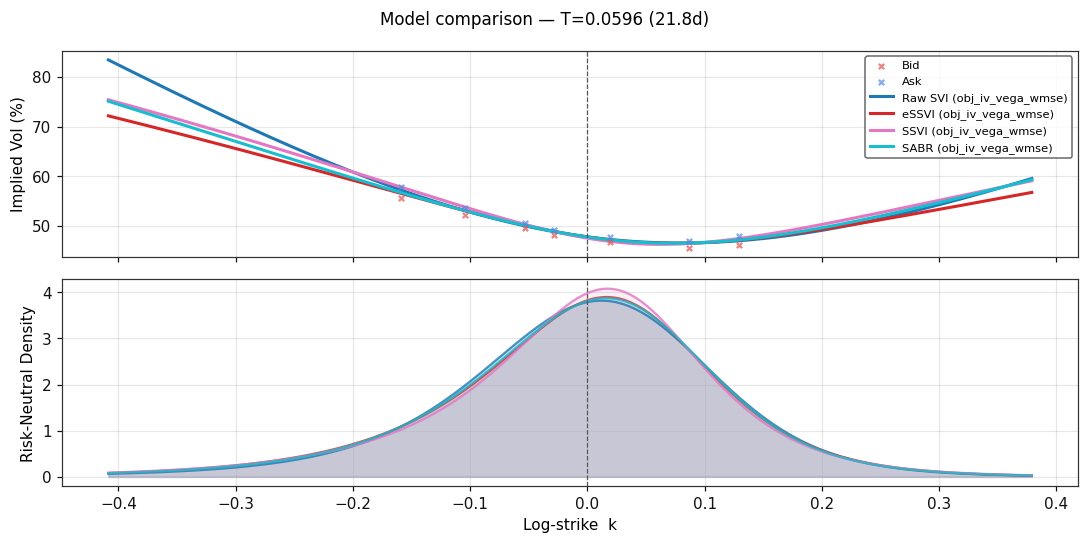

In [ ]:
# Overlay all four fitted models on one expiry.
for r, nm in [(res_svi, "Raw SVI"), (res_essvi, "eSSVI"),
              (res_ssvi, "SSVI"), (res_sabr, "SABR")]:
    r["model_name"] = nm
fig = plot_compare([res_svi, res_essvi, res_ssvi, res_sabr],
                   df=df_otm, t_exp=T0)
plt.show()

### Aggregate benchmark across snapshots

The standalone script `benchmark_objectives.py` sweeps ~10 objectives on global
eSSVI across **all** archived snapshots. If you have run it, the pickle is loaded
below; otherwise this cell is a no-op.

In [ ]:
bench_pkl = PROJECT_ROOT / "benchmark_objectives_essvi.pkl"
if bench_pkl.exists():
    import pickle
    with open(bench_pkl, "rb") as f:
        b = pickle.load(f)
    display(b["summary"].round(4))
else:
    print("Run `python volatility_surface/utils/benchmark_objectives.py` to generate this.")

,objective,spread_hit_rate_mean,spread_hit_rate_median,vwrmse_mean,vwrmse_median,iv_rmse_atm_mean,iv_rmse_atm_median
0,iv_mse,0.5765,0.5769,0.0114,0.0099,0.0102,0.0085
1,iv_wmse,0.6672,0.6800,0.0093,0.0081,0.0069,0.0060
2,vega_wmse,0.6844,0.6923,0.0107,0.0090,0.0030,0.0028
3,iv_zweighted_b0,0.7058,0.7200,0.0095,0.0084,0.0043,0.0040
4,iv_zweighted_b0.2,0.7052,0.7200,0.0092,0.0081,0.0050,0.0047
5,iv_zweighted_b0.4,0.6855,0.6842,0.0091,0.0079,0.0061,0.0054
6,iv_uniform_z,0.6602,0.6667,0.0095,0.0082,0.0067,0.0061
7,iv_convex_blend_k0.5,0.6012,0.6000,0.0099,0.0087,0.0077,0.0064
8,vega_wmse_band_l10,0.5020,0.5000,0.0116,0.0102,0.0097,0.0085
9,band_vega_midanchor,0.6188,0.6154,0.0103,0.0082,0.0072,0.0057


<a id="sec7"></a>
## 7. Static-arbitrage checking

`check_arbitrage` evaluates the fitted surface on a dense $(k, t)$ grid and tests the
two Gatheral–Jacquier conditions:

- **Calendar:** $\partial_t w \ge 0$ (total variance non-decreasing in maturity).
- **Butterfly:** $g(k, t) \ge 0$ (non-negative risk-neutral density).

`plot_arbitrage_map` renders a 2×2 diagnostic with violations overlaid in red.

In [ ]:
print('eSSVI: ')
arb = check_arbitrage(res_essvi)
print(f"Calendar  free: {arb['calendar_free']}   "
      f"worst dw/dt = {arb['calendar_worst']:+.3e}   "
      f"violations = {arb['calendar_violation_pct']:.2f}% of grid")
print(f"Butterfly free: {arb['butterfly_free']}   "
      f"worst g     = {arb['butterfly_worst']:+.3e}   "
      f"violations = {arb['butterfly_violation_pct']:.2f}% of grid")

print('\nSVI')
arb = check_arbitrage(res_svi)
print(f"Calendar  free: {arb['calendar_free']}   "
      f"worst dw/dt = {arb['calendar_worst']:+.3e}   "
      f"violations = {arb['calendar_violation_pct']:.2f}% of grid")
print(f"Butterfly free: {arb['butterfly_free']}   "
      f"worst g     = {arb['butterfly_worst']:+.3e}   "
      f"violations = {arb['butterfly_violation_pct']:.2f}% of grid")

print('\nSABR')
arb = check_arbitrage(res_sabr)
print(f"Calendar  free: {arb['calendar_free']}   "
      f"worst dw/dt = {arb['calendar_worst']:+.3e}   "
      f"violations = {arb['calendar_violation_pct']:.2f}% of grid")
print(f"Butterfly free: {arb['butterfly_free']}   "
      f"worst g     = {arb['butterfly_worst']:+.3e}   "
      f"violations = {arb['butterfly_violation_pct']:.2f}% of grid")

eSSVI: 
Calendar  free: True   worst dw/dt = +7.372e-02   violations = 0.00% of grid
Butterfly free: True   worst g     = +2.538e-01   violations = 0.00% of grid

SVI
Calendar  free: True   worst dw/dt = +2.431e-07   violations = 0.00% of grid
Butterfly free: False   worst g     = -1.110e-04   violations = 0.00% of grid

SABR
Calendar  free: True   worst dw/dt = +8.097e-02   violations = 0.00% of grid
Butterfly free: True   worst g     = +3.264e-02   violations = 0.00% of grid


eSSVI

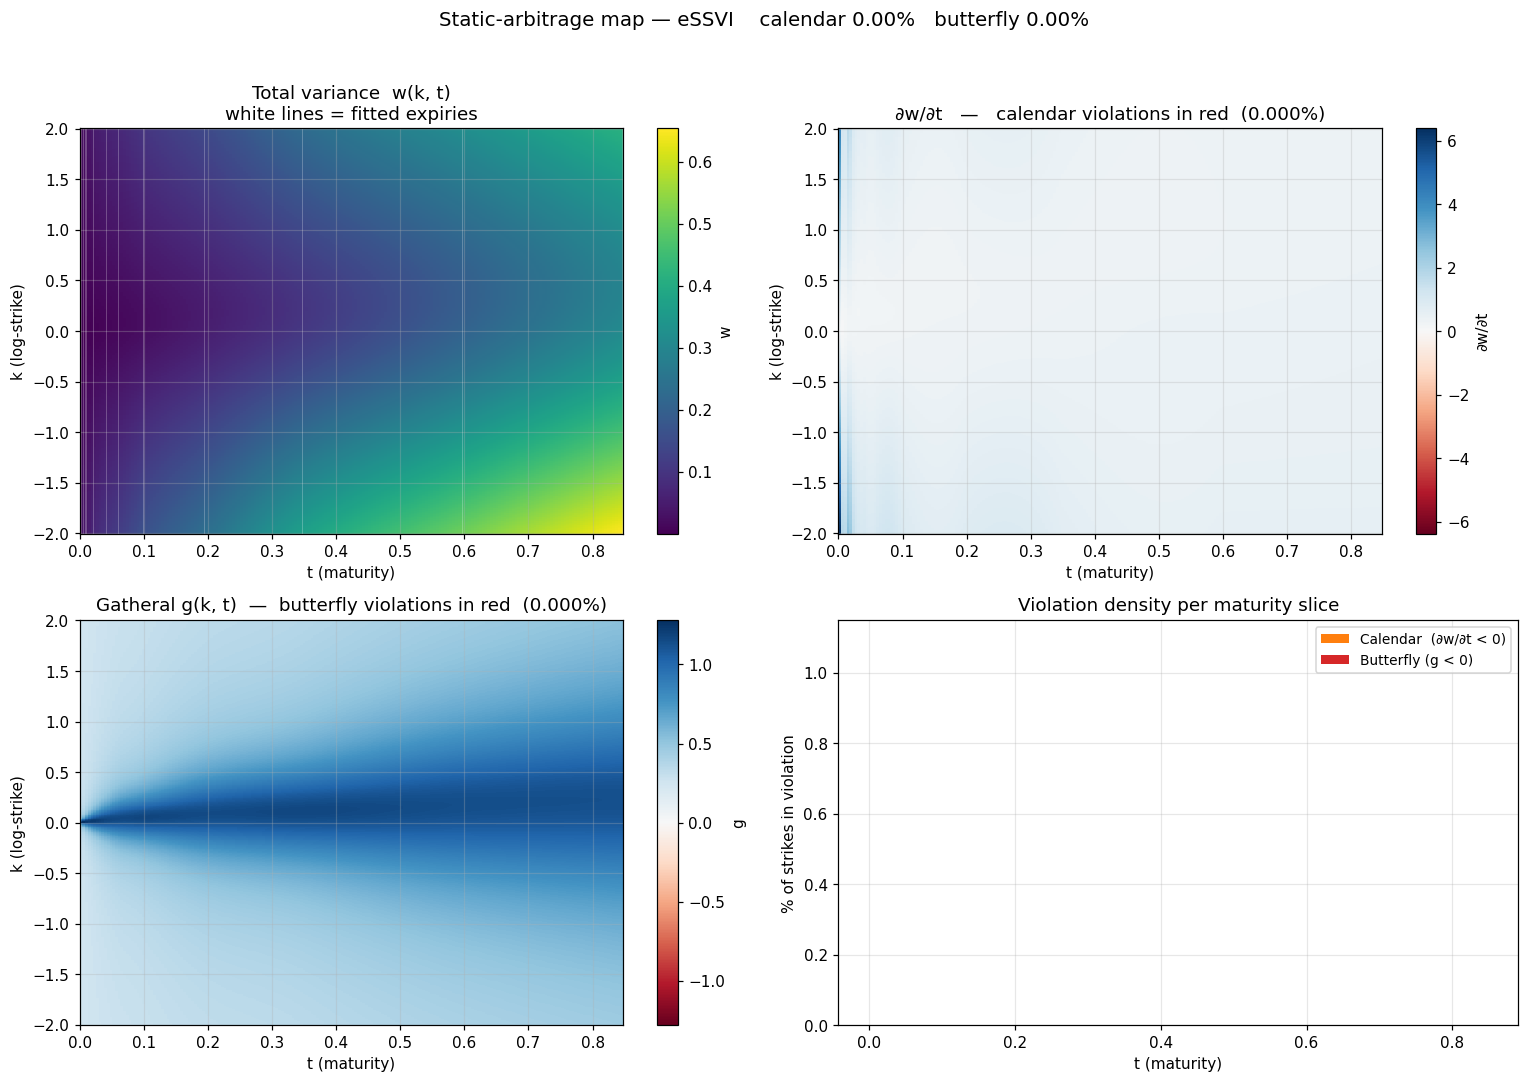

In [ ]:
fig = plot_arbitrage_map(res_essvi)
plt.show()

SVI


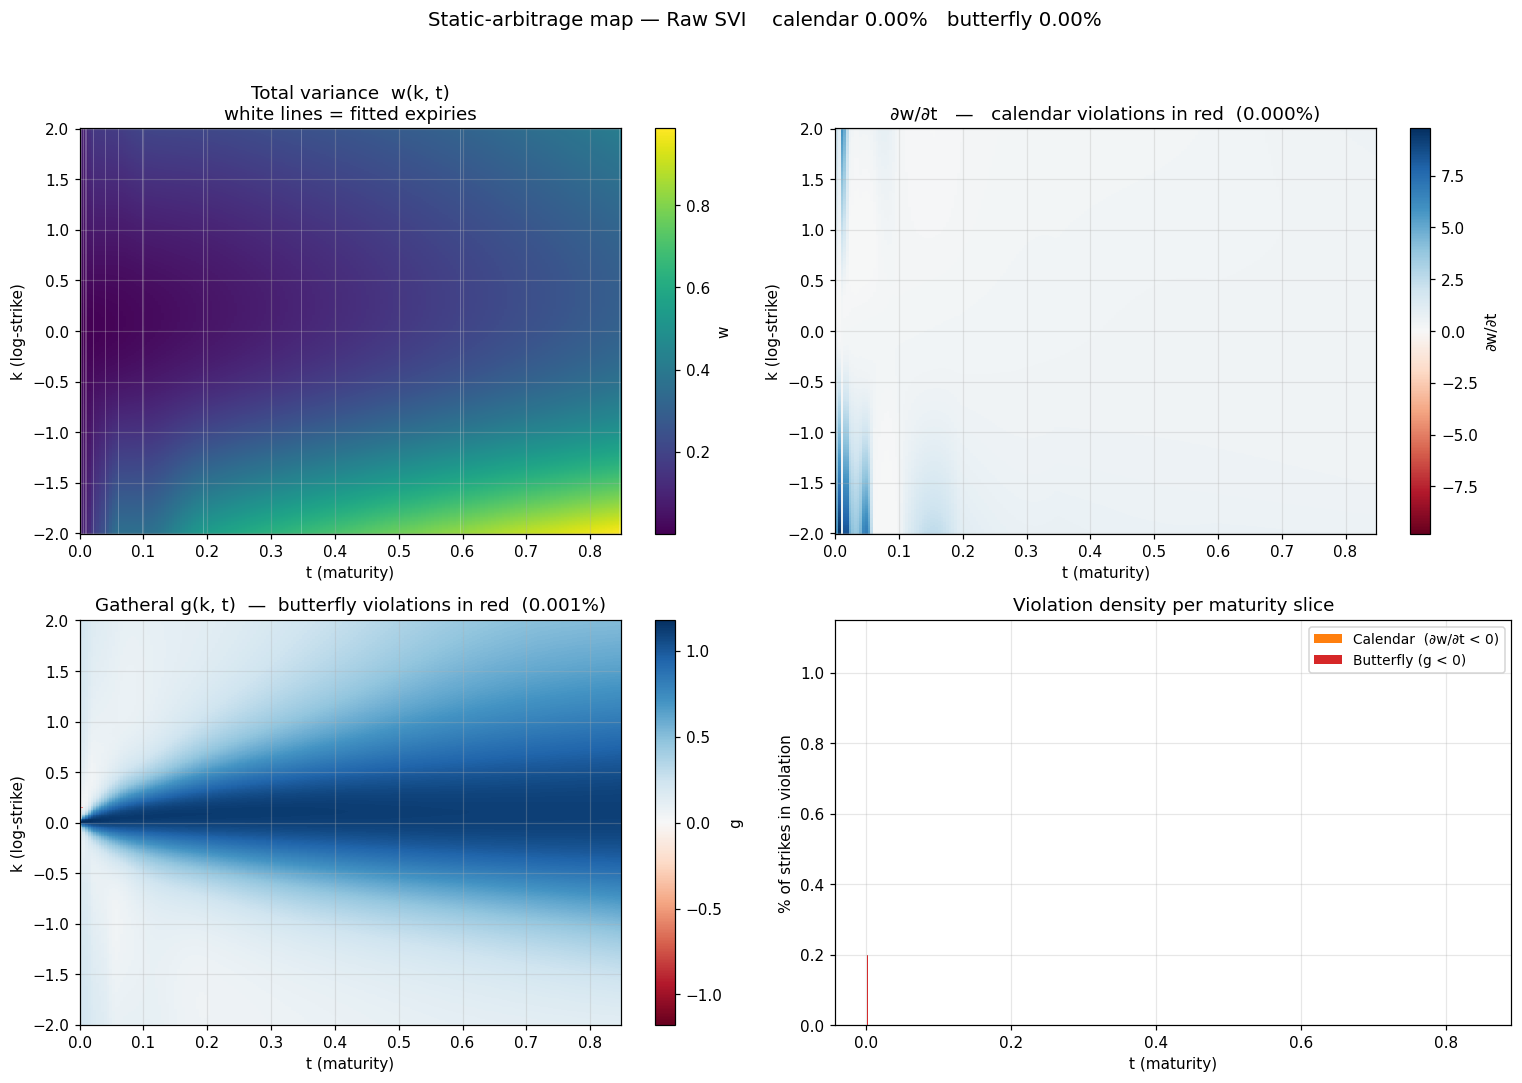

In [ ]:
fig = plot_arbitrage_map(res_svi)
plt.show()

<a id="sec8"></a>
## 8. The Reiswich–Wystup parabolic detour

The FX literature (Reiswich & Wystup, 2010) builds the smile as a **parabola in
delta space**, anchored on three quotes: ATM vol, the 25Δ risk reversal, and the
25Δ strangle. We implemented it in `models/rw_parabolic.py` with two fits:

- `fit_paper_style` — the faithful 3-point extraction.
- `fit_least_squares` — the same 3-parameter form, fit to the whole chain.

> **Finding.** It nails ATM precision by construction but **cannot bend hard enough
> for crypto wings** — on Deribit it is 3–10× worse than SABR (same parameter count).
> Right tool for a 3-quote FX market; wrong tool for a 30-strike crypto chain.

In [ ]:
F = float(sl["underlying_price"].iloc[0])
k_obs, iv_obs = sl["k"].values, sl["mark_iv"].values

p_paper = fit_paper_style(k_obs, iv_obs, T0, F)
p_ls    = fit_least_squares(k_obs, iv_obs, T0, F)
print("paper-style:", p_paper)
print("LS-refined :", p_ls)

K = F * np.exp(k_obs)
rmse = lambda p: np.sqrt(np.mean((sigma_of_K(K, F, T0, p.sigma_atm, p.sigma_rr, p.sigma_s) - iv_obs)**2))
print(f"\nRW paper-style IV RMSE: {rmse(p_paper)*100:.2f} vol-pts")
print(f"RW LS-refined  IV RMSE: {rmse(p_ls)*100:.2f} vol-pts")

paper-style: RWParams(σ_ATM=0.4752  σ_RR=-0.0459  σ_S=0.0144  F=2109  T=0.0596)
LS-refined : RWParams(σ_ATM=0.4714  σ_RR=-0.0578  σ_S=0.0204  F=2109  T=0.0596)

RW paper-style IV RMSE: 1.01 vol-pts
RW LS-refined  IV RMSE: 0.53 vol-pts


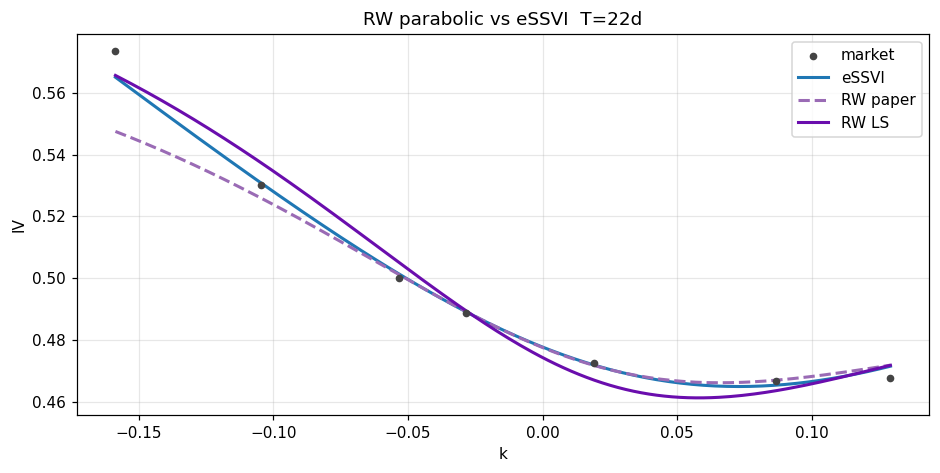

In [ ]:
Kg = F * np.exp(np.linspace(k_obs.min(), k_obs.max(), 200))
kg = np.log(Kg / F)
i_e = int(np.argmin(np.abs(np.asarray(res_essvi["expiries"]) - T0)))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.scatter(k_obs, iv_obs, s=16, c="#444", label="market", zorder=4)
ax.plot(kg, res_essvi["_model"].iv(kg, res_essvi["params"][i_e], T0), c="#1F77B4", lw=2, label="eSSVI")
ax.plot(kg, sigma_of_K(Kg, F, T0, p_paper.sigma_atm, p_paper.sigma_rr, p_paper.sigma_s), "--", c="#9A6BB5", lw=2, label="RW paper")
ax.plot(kg, sigma_of_K(Kg, F, T0, p_ls.sigma_atm, p_ls.sigma_rr, p_ls.sigma_s), c="#6A0DAD", lw=2, label="RW LS")
ax.set(xlabel="k", ylabel="IV", title=f"RW parabolic vs eSSVI  T={T0*365:.0f}d")
ax.legend(); plt.show()

<a id="sec9"></a>
## 9. Pricing models & inverse options

Three engines share the same Black skeleton and differ only in the carry term:

- **Black-76** — forward measure, no rates.
- **Black-Scholes** — drift $r$.
- **Garman-Kohlhagen** — drift $r - q$ ($q$ = funding/staking/basis for crypto).

Deribit options are **inverse**: premiums are quoted in the coin, not USD. The venue
publishes the **spot** $S$ (`estimated_delivery_price`) and the per-expiry **forward**
$F$ (`underlying_price`); the implied interest rate is $r = \ln(F/S)/t$.

In [ ]:
# Implied rate term structure from the snapshot
rate_rows = []
for t in expiries:
    s = df[np.isclose(df["t"], t)]
    F_t = float(s["underlying_price"].iloc[0])
    S_t = float(s["estimated_delivery_price"].iloc[0]) if "estimated_delivery_price" in s else F_t
    rate_rows.append({"days": round(t*365, 1), "S": S_t, "F": F_t,
                      "basis_%": (F_t/S_t - 1)*100, "implied_r_%": np.log(F_t/S_t)/t*100})
rates = pd.DataFrame(rate_rows)
display(rates.round(3))

,days,S,F,basis_%,implied_r_%
0,0.8,2108.22,2108.03,-0.009,-4.292
1,1.8,2108.22,2108.09,-0.006,-1.285
2,2.8,2108.22,2108.09,-0.006,-0.811
3,3.8,2108.22,2108.09,-0.006,-0.599
4,7.8,2108.22,2109.30,0.051,2.404
5,14.7,2108.22,2108.71,0.023,0.575
6,21.8,2108.22,2109.35,0.054,0.899
7,35.8,2108.22,2110.13,0.091,0.924
8,70.8,2108.22,2114.77,0.311,1.600
9,126.8,2108.22,2124.37,0.766,2.197


<a id="sec10"></a>
## 10. Fast recalibration (production speed)

The live screen cannot wait 50 s per tick. Two **warm-start** paths reuse the previous
fit:

- `calibrate_global_essvi_update(mode="theta_only")` — freezes every shape parameter
  and refits only the per-slice ATM levels $\theta_i$ via 1-D Brent searches.
  **~30 ms.**
- `calibrate_snapshot_sabr_update` — per-slice Nelder–Mead from the previous SABR
  params, no DE. **~5 s** (looser tolerances than the cold fit).

Below we time the eSSVI fast path against itself on a neighbouring snapshot.

In [ ]:
SNAP_TS2 = snapshots[1]
df2 = load_snapshot(str(PARQUET_ETH), timestamp=SNAP_TS2)
otm2 = ((df2["option_type"] == "C") & (df2["k"] >= 0)) | \
       ((df2["option_type"] == "P") & (df2["k"] <= 0))
df2_otm = df2[otm2].copy()

t0 = time.perf_counter()
res_fast = calibrate_global_essvi_update(
    df2_otm, prev_result=res_essvi, model=res_essvi["_model"],
    objective="vega_wmse", mode="theta_only",
    vega_col="vega", bid_col="bid_iv", ask_col="ask_iv", verbose=False,
)
dt = (time.perf_counter() - t0) * 1000
print(f"eSSVI theta-only update on the next snapshot: {dt:.1f} ms "
      f"({len(res_fast['expiries'])} slices)")

  215 rows in snapshot
  215 rows after cleaning (dropped 0)
eSSVI theta-only update on the next snapshot: 32.4 ms (12 slices)


In [ ]:
# SABR warm-start update (~5 s) — needs a SABR seed.
t0 = time.perf_counter()
res_sabr_fast = calibrate_snapshot_sabr_update(
    df2_otm, prev_result=res_sabr, objective="vega_wmse",
    vega_col="vega", bid_col="bid_iv", ask_col="ask_iv", verbose=False,
)
print(f"SABR warm-start update: {time.perf_counter()-t0:.1f}s  "
      f"(vs ~50 s cold)")

SABR warm-start update: 1.4s  (vs ~50 s cold)


<a id="sec11"></a>
## 11. The live system

Everything above is wired into a **per-second trading screen**. Architecture:

```
   Deribit REST  ──┐        Deribit WS (ticker.*)
   (book summary)  │              (top-of-book sizes)
                   ▼                     │
        live_gather.py  ◀───────────────┘
          clean_live() → OTM filter → IV inversion
          atomic append → rolling parquet (60-min window)
                   │
                   ▼
        streamlit_chain.py
          read latest snapshot
          first tick : full eSSVI / SABR  (cold, cached)
          each tick  : theta-only / warm-start update
          render option chain  +  maturity tabs  +  arb banner
```

Launch both gatherers (ETH + BTC) and the UI with one command:

```bash
./run_live.sh           # both currencies, 1 s polling
```

The screen mirrors a Deribit-style chain: invariant greeks on the left, the smile
vol, call/put markets either side of a black **STRIKE** column (ATM highlighted
yellow), bid/ask **sizes** from the websocket, and theo prices that turn **red** when
they fall outside the quoted spread. A top banner flags any **calendar-spread
arbitrage** detected across the fitted expiries.

*(These run as separate processes — not executed here.)*

In [ ]:
# Sanity: the calendar-arb detector the live banner uses.
exp_arr = np.asarray(res_essvi["expiries"])
order = np.argsort(exp_arr)
worst = 0.0
for i in range(len(order)-1):
    a, b = order[i], order[i+1]
    worst = max(worst, crossedness(res_essvi["_model"],
                                   res_essvi["params"][a], res_essvi["params"][b]))
print(f"Worst calendar crossing in the eSSVI surface: {worst:.3e}",
      "(>1e-6 would flag the red banner)")

Worst calendar crossing in the eSSVI surface: 0.000e+00 (>1e-6 would flag the red banner)


<a id="sec12"></a>
## 12. Trials & errors

The honest version of the project — what broke and what we learned:

1. **β tuning over-fit on few dates.** `iv_zweighted(β=0.4)` won on ~10 ETH dates;
   the edge vanished on the full set. Settled on plain **vega-weighting**.
2. **SVI-JW degeneracy.** With $\rho\approx 0$ and $\psi\approx 0$, the JW→raw map is
   singular; a tiny skew change produced a huge $\sigma$ and a flat smile. Fixed with
   an explicit degeneracy guard + UI warning.
3. **Inverse-option units.** Black-76 returns USD; Deribit quotes in the coin. Every
   theo had to be divided by $F$ — otherwise the whole chain flagged false arbitrage.
4. **IV inversion returned `None`.** `implied_volatility_dataframe` returned a scalar
   `None` on invalid quotes, which collapsed the `df[["bid_iv","ask_iv"]]` assignment
   with *"Columns must be same length as key"* and froze the gatherer. Fixed by always
   returning a `(nan, nan)` pair.
5. **Streamlit `@st.cache_resource` evicts on file save.** Switching models forced a
   50 s recompute. Fixed by keeping the warm-start fit in `st.session_state` keyed by
   `(currency, model)`.
6. **Hard-coded currency.** The app always read `live_eth.parquet`; selecting BTC
   showed stale data. Fixed with a per-currency parquet resolver + auto-detect of the
   freshest feed.
7. **One snapshot is not a result.** The recurring theme — every promising single-snapshot
   finding had to survive a multi-snapshot benchmark before we trusted it.

<a id="sec13"></a>
## 13. Conclusion & next steps

We built an end-to-end, **arbitrage-aware** volatility-surface library for crypto
options: a cleaning pipeline, four calibratable smile models, a registry of
liquidity-aware objectives, static-arbitrage diagnostics, and a per-second live
trading screen powered by warm-start recalibration.

**What worked.** eSSVI with vega-weighting gives a coherent, near-arbitrage-free
surface; the theta-only fast path keeps it live at 30 ms/tick. SABR is the best
3-parameter per-slice baseline.

**Open questions / next steps.**
- Parallelise the SABR warm-start (per-slice, embarrassingly parallel) to reach 1 Hz.
- Regime-dependent objective or smooth $\beta(\text{spread})$ instead of a hard switch.
- Re-invert bid/ask IVs under each pricing engine for a fully consistent model bake-off.
- Extend the RW parabola (cubic/quartic in delta) to test whether the wing miss is one
  free parameter away from being fixed.

---
*End of walkthrough.*